# Emergency Pathfinding Project (Germany)
Using OSMnx, NetworkX, Dijkstra and A*

In [1]:
!pip install osmnx networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.0 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random

In [3]:
city = "Heidelberg, Germany"
G = ox.graph_from_place(city, network_type='drive')
print("Graph loaded with", len(G.nodes), "nodes")

Graph loaded with 2857 nodes


In [4]:
tags = {"amenity": "hospital"}
hospitals = ox.features_from_place(city, tags)
hospitals = hospitals[hospitals.geometry.type == "Point"]
print("Hospitals found:", len(hospitals))

Hospitals found: 6


In [6]:
G = G.to_undirected()

In [7]:
hospital_nodes = []

for _, row in hospitals.iterrows():
    try:
        x = row.geometry.x
        y = row.geometry.y
        nearest_node = ox.distance.nearest_nodes(G, x, y)
        hospital_nodes.append(nearest_node)
    except:
        continue

hospital_nodes = list(set(hospital_nodes))
print("Mapped hospital nodes:", len(hospital_nodes))

Mapped hospital nodes: 4


In [8]:
start_node = random.choice(list(G.nodes))
print("Start node:", start_node)

Start node: 410654152


In [9]:
shortest_path_dijkstra = None
min_dist = float("inf")

for hospital in hospital_nodes:
    try:
        length = nx.shortest_path_length(G, start_node, hospital, weight="length")
        if length < min_dist:
            min_dist = length
            shortest_path_dijkstra = nx.shortest_path(G, start_node, hospital, weight="length")
    except:
        continue

print("Dijkstra distance:", min_dist)

Dijkstra distance: 2646.587962735463


In [10]:
def heuristic(u, v):
    x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
    return ((x1 - x2)**2 + (y1 - y2)**2)**0.5

shortest_path_astar = None
min_dist_astar = float("inf")

for hospital in hospital_nodes:
    try:
        path = nx.astar_path(G, start_node, hospital, heuristic=heuristic, weight="length")
        length = nx.path_weight(G, path, weight="length")
        if length < min_dist_astar:
            min_dist_astar = length
            shortest_path_astar = path
    except:
        continue

print("A* distance:", min_dist_astar)

A* distance: 2646.587962735463


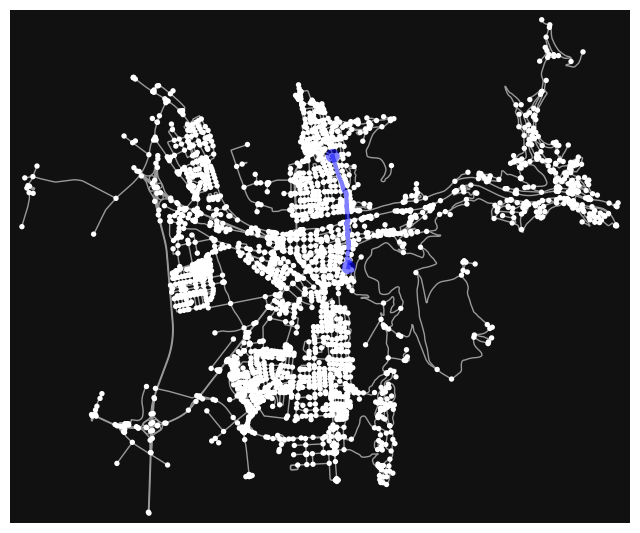

In [11]:
fig, ax = ox.plot_graph(G, show=False, close=False)

if shortest_path_dijkstra:
    ox.plot_graph_route(G, shortest_path_dijkstra, ax=ax, route_color="blue", route_linewidth=3, node_size=0)

if shortest_path_astar:
    ox.plot_graph_route(G, shortest_path_astar, ax=ax, route_color="red", route_linewidth=3, node_size=0)

plt.show()

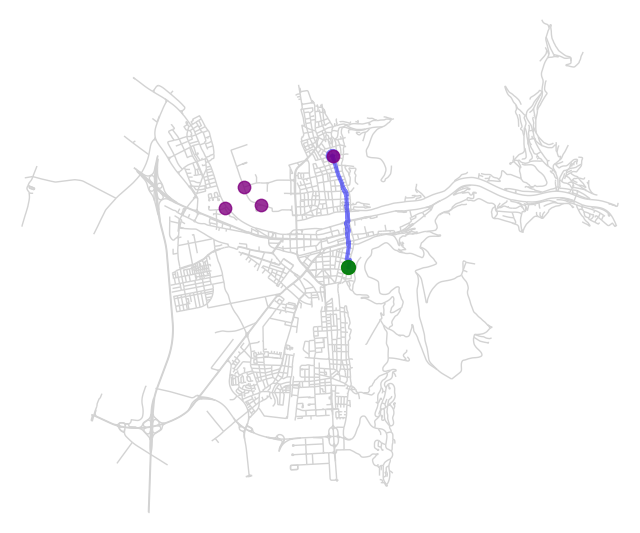

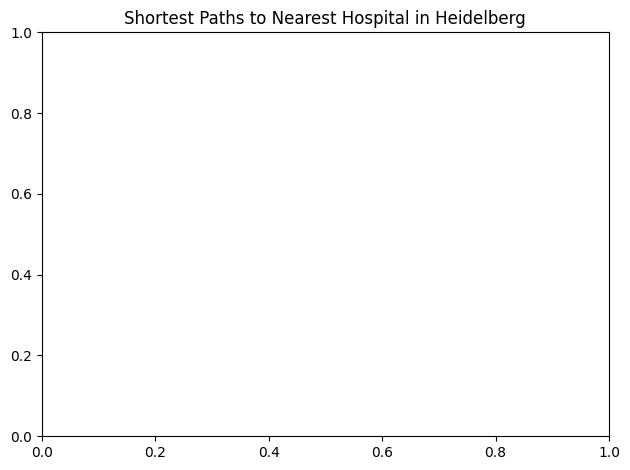

In [13]:
fig, ax = ox.plot_graph(G, show=False, close=False, bgcolor='white', edge_color='lightgray', node_size=0)

# Get coordinates for the start node
start_node_x, start_node_y = G.nodes[start_node]['x'], G.nodes[start_node]['y']
# Plot the start node
ax.scatter(start_node_x, start_node_y, color='green', s=100, zorder=5, alpha=0.9, label='Start Node')

# Get coordinates for the hospital nodes
hospital_xs = [G.nodes[node]['x'] for node in hospital_nodes]
hospital_ys = [G.nodes[node]['y'] for node in hospital_nodes]
# Plot the hospital nodes
ax.scatter(hospital_xs, hospital_ys, color='purple', s=80, zorder=4, alpha=0.8, label='Hospital Nodes')

if shortest_path_dijkstra:
    ox.plot_graph_route(G, shortest_path_dijkstra, ax=ax, route_color="blue", route_linewidth=3, node_size=0, label='Dijkstra Path')

if shortest_path_astar:
    ox.plot_graph_route(G, shortest_path_astar, ax=ax, route_color="red", route_linewidth=3, node_size=0, label='A* Path')

# Add a legend to differentiate paths and nodes
ax.legend()
plt.title("Shortest Paths to Nearest Hospital in Heidelberg")
plt.tight_layout()
plt.show()